In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("taco_sales_(2024-2025).csv")

In [3]:
df.head()

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order
0,770487,El Taco Loco,New York,01-08-2024 14:55,01-08-2024 15:36,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False
1,671858,El Taco Loco,San Antonio,23-11-2024 17:11,23-11-2024 17:25,14,Regular,Beef Taco,1,6.20,4.25,3.01,True
2,688508,Taco Haven,Austin,21-11-2024 20:24,21-11-2024 21:02,38,Large,Pork Taco,2,20.33,7.00,0.02,False
3,944962,Spicy Taco House,Dallas,21-09-2024 06:43,21-09-2024 07:28,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True
4,476417,Casa del Taco,San Antonio,24-07-2024 11:01,24-07-2024 11:16,15,Large,Pork Taco,0,24.34,4.50,1.14,False


In [4]:
print("\nDataset Shape")
print(df.shape)

print(f"\nNumber of Records (Rows): {df.shape[0]}")
print(f"Number of Variables (Columns): {df.shape[1]}")

# ==========================================
# Step 6: Data Types
# ==========================================
print("\nData Types")
print(df.dtypes)

# ==========================================
# Step 7: General Information
# ==========================================
print("\nDataset Information")
print(df.info())

# ==========================================
# Step 8: Missing Values
# ==========================================
print("\nMissing Values Per Column")
print(df.isnull().sum())

print("\nTotal Missing Values")
print(df.isnull().sum().sum())

# ==========================================
# Step 9: Duplicate Records
# ==========================================
duplicates = df.duplicated().sum()

print("\nDuplicate Records")
print(duplicates)

# ==========================================
# Step 10: Remove Duplicates (Optional)
# ==========================================
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates")
print(df.shape)

# ==========================================
# Step 11: Descriptive Statistics
# ==========================================
print("\nDescriptive Statistics")
print(df.describe())

# ==========================================
# Step 12: Unique Values in Each Variable
# ==========================================
print("\nUnique Values Per Column")
print(df.nunique())

# ==========================================
# Step 13: Check for Empty Strings
# ==========================================
print("\nEmpty Strings Per Column")
print((df == "").sum())


Dataset Shape
(1000, 13)

Number of Records (Rows): 1000
Number of Variables (Columns): 13

Data Types
Order ID                     int64
Restaurant Name             object
Location                    object
Order Time                  object
Delivery Time               object
Delivery Duration (min)      int64
Taco Size                   object
Taco Type                   object
Toppings Count               int64
Distance (km)              float64
Price ($)                  float64
Tip ($)                    float64
Weekend Order                 bool
dtype: object

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order ID                 1000 non-null   int64  
 1   Restaurant Name          1000 non-null   object 
 2   Location                 1000 non-null   object 
 3   Order Time               

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order ID                 1000 non-null   int64  
 1   Restaurant Name          1000 non-null   object 
 2   Location                 1000 non-null   object 
 3   Order Time               1000 non-null   object 
 4   Delivery Time            1000 non-null   object 
 5   Delivery Duration (min)  1000 non-null   int64  
 6   Taco Size                1000 non-null   object 
 7   Taco Type                1000 non-null   object 
 8   Toppings Count           1000 non-null   int64  
 9   Distance (km)            1000 non-null   float64
 10  Price ($)                1000 non-null   float64
 11  Tip ($)                  1000 non-null   float64
 12  Weekend Order            1000 non-null   bool   
dtypes: bool(1), float64(3), int64(3), object(6)
memory usage: 94.9+ KB


In [6]:
df["Order Time"] = pd.to_datetime(df["Order Time"], dayfirst=True)
df["Delivery Time"] = pd.to_datetime(df["Delivery Time"], dayfirst=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order ID                 1000 non-null   int64         
 1   Restaurant Name          1000 non-null   object        
 2   Location                 1000 non-null   object        
 3   Order Time               1000 non-null   datetime64[ns]
 4   Delivery Time            1000 non-null   datetime64[ns]
 5   Delivery Duration (min)  1000 non-null   int64         
 6   Taco Size                1000 non-null   object        
 7   Taco Type                1000 non-null   object        
 8   Toppings Count           1000 non-null   int64         
 9   Distance (km)            1000 non-null   float64       
 10  Price ($)                1000 non-null   float64       
 11  Tip ($)                  1000 non-null   float64       
 12  Weekend Order            1000 non-n

## Creating new columns
# Month
# Hour
# Day of week
# Tip Percentage

In [8]:
df["Month"] = df["Order Time"].dt.month_name()
df["Hour"] = df["Order Time"].dt.hour
df["Day"] = df["Order Time"].dt.day_name()
df["Tip %"] = (df["Tip ($)"] / df["Price ($)"]) * 100

In [9]:
df.head()

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order,Month,Hour,Day,Tip %
0,770487,El Taco Loco,New York,2024-08-01 14:55:00,2024-08-01 15:36:00,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False,August,14,Thursday,24.000000
1,671858,El Taco Loco,San Antonio,2024-11-23 17:11:00,2024-11-23 17:25:00,14,Regular,Beef Taco,1,6.20,4.25,3.01,True,November,17,Saturday,70.823529
2,688508,Taco Haven,Austin,2024-11-21 20:24:00,2024-11-21 21:02:00,38,Large,Pork Taco,2,20.33,7.00,0.02,False,November,20,Thursday,0.285714
3,944962,Spicy Taco House,Dallas,2024-09-21 06:43:00,2024-09-21 07:28:00,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True,September,6,Saturday,34.545455
4,476417,Casa del Taco,San Antonio,2024-07-24 11:01:00,2024-07-24 11:16:00,15,Large,Pork Taco,0,24.34,4.50,1.14,False,July,11,Wednesday,25.333333


In [10]:
# Which restaurants make the most money?
restaurant_revenue = df.groupby("Restaurant Name")["Price ($)"].sum()

restaurant_revenue

Restaurant Name
Casa del Taco        708.75
El Taco Loco         574.00
Grande Tacos         727.00
La Vida Taco         666.25
Spicy Taco House     732.75
Taco Fiesta          712.00
Taco Haven           654.00
Taco Time Express    616.75
The Taco Stand       722.25
Urban Tacos          794.50
Name: Price ($), dtype: float64

In [11]:
# Sort from highest to lowest:
restaurant_revenue = restaurant_revenue.sort_values(ascending=False)

restaurant_revenue

Restaurant Name
Urban Tacos          794.50
Spicy Taco House     732.75
Grande Tacos         727.00
The Taco Stand       722.25
Taco Fiesta          712.00
Casa del Taco        708.75
La Vida Taco         666.25
Taco Haven           654.00
Taco Time Express    616.75
El Taco Loco         574.00
Name: Price ($), dtype: float64

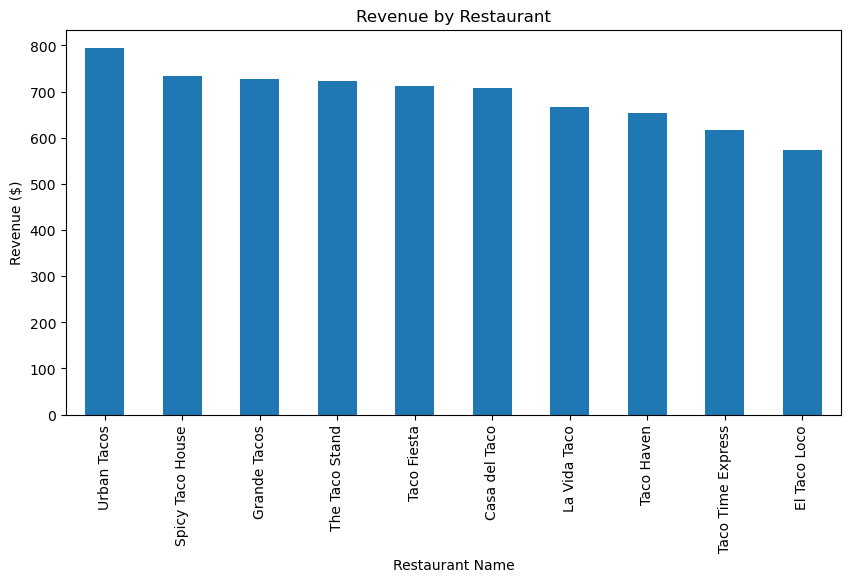

In [12]:
# Plot
restaurant_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Revenue by Restaurant")
plt.ylabel("Revenue ($)")
plt.show()

In [13]:
# Which locations generate the highest revenue?
location_revenue = df.groupby("Location")["Price ($)"].sum()

location_revenue = location_revenue.sort_values(ascending=False)

location_revenue

Location
Chicago        795.50
San Antonio    768.25
Los Angeles    737.50
Houston        715.00
San Jose       683.75
New York       676.25
San Diego      669.50
Phoenix        667.25
Austin         640.50
Dallas         554.75
Name: Price ($), dtype: float64

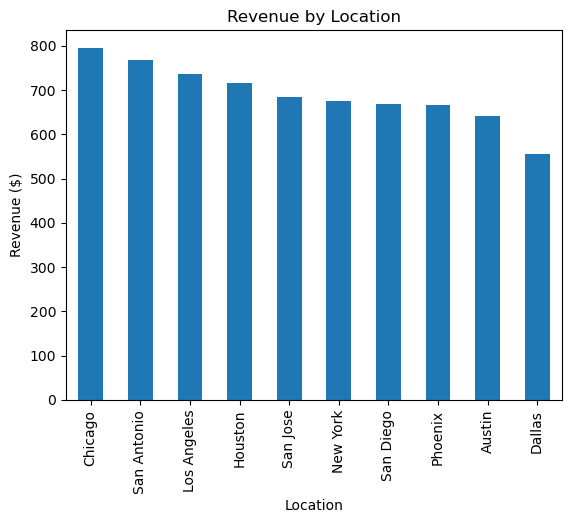

In [14]:
#Plot
location_revenue.plot(kind="bar")

plt.title("Revenue by Location")
plt.ylabel("Revenue ($)")
plt.show()

In [15]:
# Ordering pattern by hour
orders_hour = df.groupby("Hour")["Order ID"].count()

orders_hour

Hour
0     41
1     42
2     48
3     38
4     52
5     50
6     34
7     45
8     37
9     40
10    46
11    36
12    41
13    38
14    40
15    39
16    45
17    43
18    47
19    35
20    39
21    45
22    39
23    40
Name: Order ID, dtype: int64

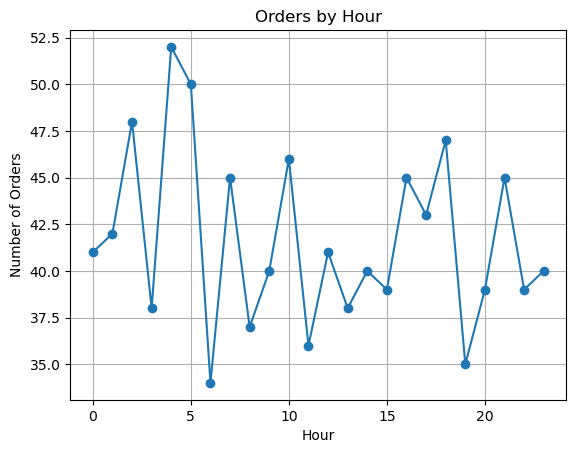

In [16]:
#Plot
orders_hour.plot(marker='o')

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.grid()
plt.show()

In [17]:
# Average spending
average_spending = df["Price ($)"].mean()

print(average_spending)

6.90825


In [18]:
#Average tip
average_tip = df["Tip ($)"].mean()

print(average_tip)

1.80611


In [19]:
#Delivery performance
delivery = df.groupby("Restaurant Name")["Delivery Duration (min)"].mean()

delivery = delivery.sort_values()

delivery

Restaurant Name
La Vida Taco         47.051020
El Taco Loco         48.235294
Taco Fiesta          49.939394
Casa del Taco        50.298077
Grande Tacos         51.481132
Urban Tacos          51.641026
Spicy Taco House     51.900000
Taco Haven           51.936842
Taco Time Express    52.714286
The Taco Stand       53.561905
Name: Delivery Duration (min), dtype: float64

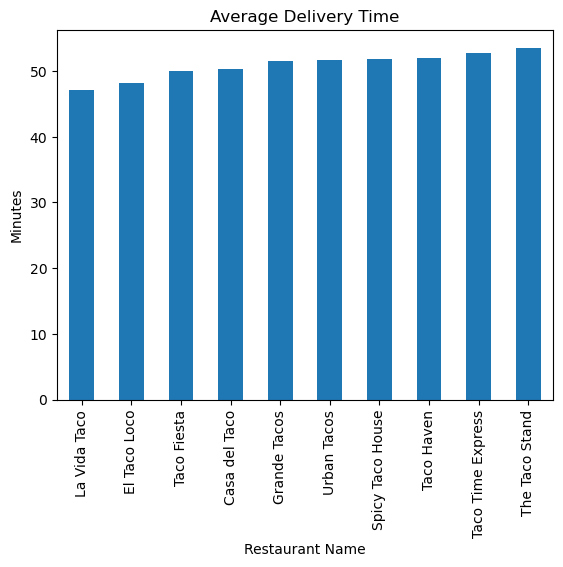

In [20]:
#Plot
delivery.plot(kind="bar")

plt.title("Average Delivery Time")
plt.ylabel("Minutes")
plt.show()

In [21]:
#Restaurants with the longest delivery times
slowest = df.groupby("Restaurant Name")["Delivery Duration (min)"].mean().sort_values(ascending=False)

print(slowest)

Restaurant Name
The Taco Stand       53.561905
Taco Time Express    52.714286
Taco Haven           51.936842
Spicy Taco House     51.900000
Urban Tacos          51.641026
Grande Tacos         51.481132
Casa del Taco        50.298077
Taco Fiesta          49.939394
El Taco Loco         48.235294
La Vida Taco         47.051020
Name: Delivery Duration (min), dtype: float64


In [22]:
# Weekend vs Weekday revenue
weekend = df.groupby("Weekend Order")["Price ($)"].sum()

print(weekend)

Weekend Order
False    5007.25
True     1901.00
Name: Price ($), dtype: float64


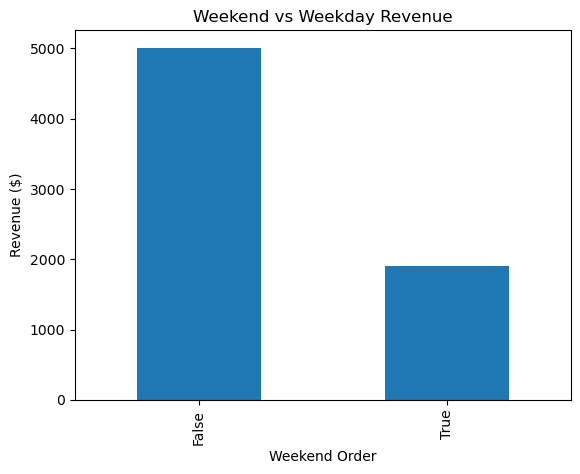

In [23]:
#Plot
weekend.plot(kind="bar")

plt.title("Weekend vs Weekday Revenue")
plt.ylabel("Revenue ($)")
plt.show()

C:\Users\emera\AppData\Local\Temp\ipykernel_8412\3723031015.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip = df.groupby("Spending Range")["Tip ($)"].mean()


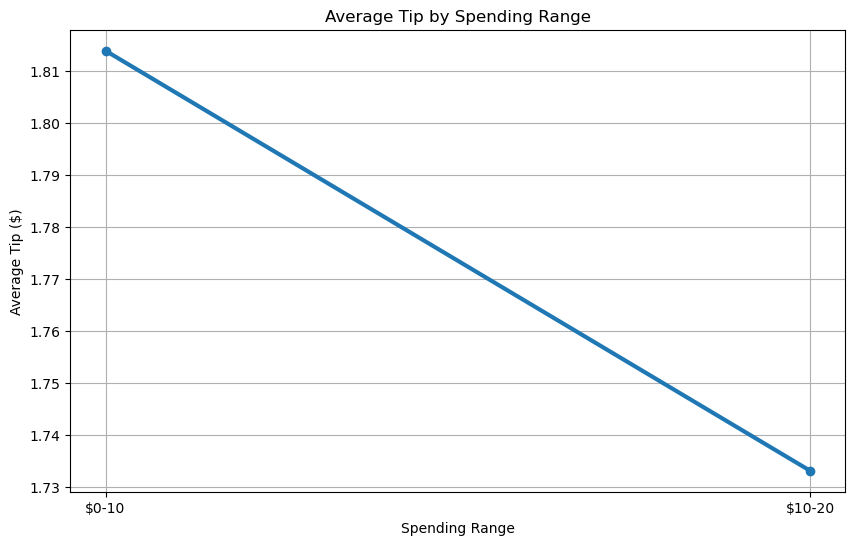

In [24]:
# Create spending ranges
bins = [0, 10, 20, 30, 40, 50, 60]
labels = ["$0-10", "$10-20", "$20-30", "$30-40", "$40-50", "$50-60"]

df["Spending Range"] = pd.cut(df["Price ($)"], bins=bins, labels=labels)

# Calculate average tip for each spending range
avg_tip = df.groupby("Spending Range")["Tip ($)"].mean()

# Plot
plt.figure(figsize=(10,6))
plt.plot(avg_tip.index.astype(str),
         avg_tip.values,
         marker='o',
         linewidth=3)

plt.title("Average Tip by Spending Range")
plt.xlabel("Spending Range")
plt.ylabel("Average Tip ($)")
plt.grid(True)

plt.show()